<a href="https://colab.research.google.com/github/BrunoCapron/ESQ724-fundamentos_aprendizado_maquina/blob/main/Redes_Neuronais/MLP_Classificao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP para classificação

In [ ]:
import tensorflow as tf
from tensorflow import keras

tf.__version__
keras.__version__

'3.10.0'

A partir do conjunto de imagens Fashion MINST, o objetivo é treinar uma rede capaz de identificar itens de vestimenta. O conjunto de dados contém 70000 imagens de 28*28 pixels, com 10 classes.

Carregamos o conjunto de dados e criamos os conjuntos de dados de treinamento e teste

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train_full.shape

(60000, 28, 28)

Cada imagem é representada por meio de matriz 28x28 em vez de uma coluna de 784 linhas, como no MNIST.

Criamos um subconjunto de dados de validação, e escalonamos as intensidades de pixels na faixa de 0 a 1

In [ ]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

As classes do conjunto de dados:

In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
y_train[0]
class_names[y_train[0]]

'Coat'

Construimos agora a rede neuronal: Uma MLP com duas camadas escondidas.

In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28])) # ou model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

A primeira linha cria o modelo sequencial, o modelo mais simples de se construir: um conjunto de camadas conectadas sequencialmente.


Na segunda linhas, é criada e acrescentada ao modelo a primeira camada (a camada de entrada. O atributo Flatten é usado para converta a matriz em um vetor.

Nas duas linhas seguintes, são  criadas e acrescentadas 2 camadas escondidas Dense (os neurônios da camada são conectados a todos os neurônios da camada anterior) de 300 e 100 neurônios, com função de ativação ReLU.

Finalmente, na última linha, uma camada de saida Dense com 10 neurônios (1 por classe) e função de ativação softmax é criada.


Forma equivalente de criar o modelo

In [ ]:
# model = keras.models.Sequential([
#  keras.layers.Flatten(input_shape=[28, 28]),
#  keras.layers.Dense(300, activation="relu"),
#  keras.layers.Dense(100, activation="relu"),
#  keras.layers.Dense(10, activation="softmax")
#  ])

Camadas densas tem um grande número de parâmetros. Dá bastante flexibilidade para o treino, mas corre-se o risco do modelo sobre-ajustar os dados, especialmente se a quantidade de dados não é grande.

Os parâmentros de uma determinada camada podem ser obtidos por meio de:

In [ ]:
hidden1 = model.layers[1]
weights, biases = hidden1.get_weights()
#print(weights)
print(biases)
biases.shape


[ 0.00429702  0.23745364  0.19833337  0.12042759 -0.01130029  0.00641199
 -0.11080261 -0.01911548  0.08010624  0.00240421  0.08549816 -0.02837599
 -0.01217797 -0.04781741  0.20833199  0.08350682  0.19815718 -0.21121193
  0.02729091 -0.02972654  0.0013424   0.14510117 -0.07489227  0.13566057
  0.1932188   0.10456666 -0.10157134  0.11127753 -0.01758108  0.06333941
 -0.10179543  0.03585383 -0.14112873 -0.03301423  0.25259972 -0.17943911
  0.2531941   0.101744    0.0897805  -0.06476413  0.04981041  0.00254325
  0.10352145 -0.0271725   0.03888795 -0.13367718 -0.0492809   0.00427961
  0.2442101   0.06220884  0.21523173  0.13158527  0.10157737  0.17995705
 -0.18014294  0.0560444   0.10851642 -0.13743064 -0.04462413  0.10037194
  0.21238007  0.08067646  0.29087988  0.03907128 -0.03207115  0.03228174
  0.198913    0.51069456  0.01479773  0.04063647 -0.15243171  0.04612807
 -0.07021546  0.10623532  0.1397524   0.03172746  0.32887542 -0.12750609
  0.10081902  0.12268177  0.11994858 -0.05522132  0

(300,)

Depois de ter criado o modelo, o método compile() deve ser chamado para especificar a função perda e otimizador a ser utilizado. Adicionalmente, uma lista de metricas a computar durante o treinamento e a avaliação pode ser especificada.

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
 optimizer="sgd",
 metrics=["accuracy"])

Usa "sparce_categorical_crossentropy" quando uma instância somente pode pertencer a uma classe (as classes são exclusivas).
O modelo é treinado através do método de gradiente Descendente Estocástico simples. A taxa de aprendizado pode ser ajustada através de optimizer=keras.optimizers.SGD(lr=???). O valor Default é 0,01.


O modelo está pronto para ser treinado através do método fit()

In [ ]:
history = model.fit(X_train, y_train, epochs=27, validation_data=(X_valid, y_valid))

Epoch 1/27
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9006 - val_loss: 0.5881
Epoch 2/27
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9036 - val_loss: 0.5863
Epoch 3/27
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9018 - val_loss: 0.5889
Epoch 4/27
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9018 - val_loss: 0.5941
Epoch 5/27
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9036 - val_loss: 0.5937
Epoch 6/27
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9010 - val_loss: 0.5901
Epoch 7/27
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9010 - val_loss: 0.5959
Epoch 8/27
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 1.0000 - loss: 0.0021 -

O treino é realizado através de mini bateladas de 32 instâncias

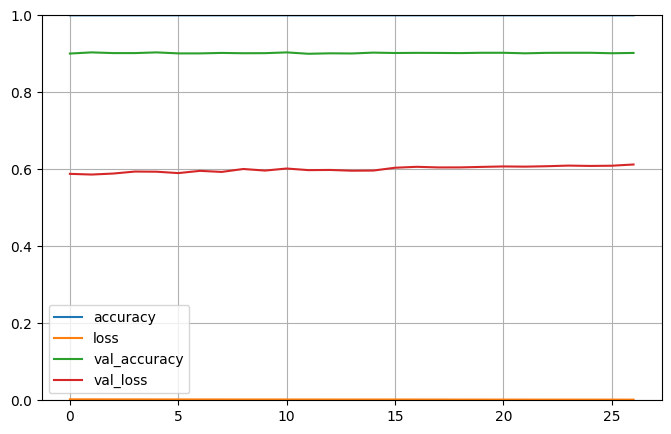

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

Avaliação do modelo em cima do conjunto de teste

In [ ]:
model.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8513 - loss: 207.5629


[205.6002655029297, 0.8496999740600586]

Usamos agora o modelo para fazer predições

In [ ]:
X_new = X_test[:3]
y_proba = model.predict(X_new) #retorna as probabilidades das instâncias pertencerem às diferentes classes
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
import numpy as np

y_pred = np.argmax(y_proba, axis=1) #retorna a classe mais provável para cada instância
print(y_pred)
np.array(class_names)[y_pred]

[9 2 1]


array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')